# One-Hot Encoding for Labels - Logistic Regression

Using one-vs-rest (OvR) scheme 

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('logistic_reg_labels.csv')
df.head(10)

,x1,x2,label
0,52.391513,107.483053,B
1,27.140204,109.209526,B
2,62.585840,-50.368880,C
3,-44.273343,0.272521,A
4,61.132981,-42.934972,C
5,66.426433,-37.689998,C
6,-54.882594,-1.364713,A
7,56.925126,-59.311140,C
8,-57.480599,2.133231,A
9,63.250653,-56.675013,C


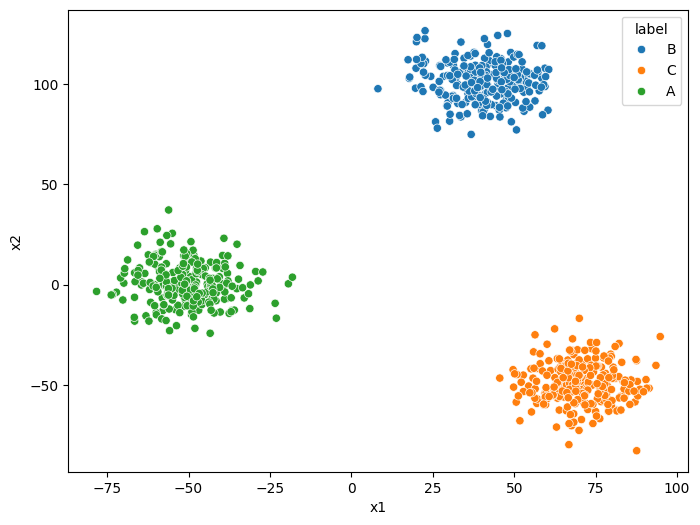

In [3]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['x1'],y=df['x2'],hue=df['label']);

In [4]:
from sklearn.linear_model import LogisticRegression

In [5]:
X = df[['x1','x2']].to_numpy()
X[:10]

array([[ 52.39151314, 107.48305254],
       [ 27.14020392, 109.20952648],
       [ 62.58584   , -50.36887977],
       [-44.27334325,   0.27252127],
       [ 61.13298135, -42.93497207],
       [ 66.42643283, -37.6899983 ],
       [-54.88259445,  -1.36471304],
       [ 56.9251256 , -59.31113993],
       [-57.48059858,   2.13323064],
       [ 63.25065268, -56.67501269]])

In [6]:
y = df['label'].to_numpy()
y[:10]

array(['B', 'B', 'C', 'A', 'C', 'C', 'A', 'C', 'A', 'C'], dtype=object)

In [7]:
reg = LogisticRegression()
reg.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
reg.coef_

array([[-0.23097904, -0.01050259],
       [ 0.07971867,  0.09003002],
       [ 0.15126037, -0.07952743]])

In [9]:
reg.intercept_

array([ 0.01164669, -0.00996   , -0.00168668])

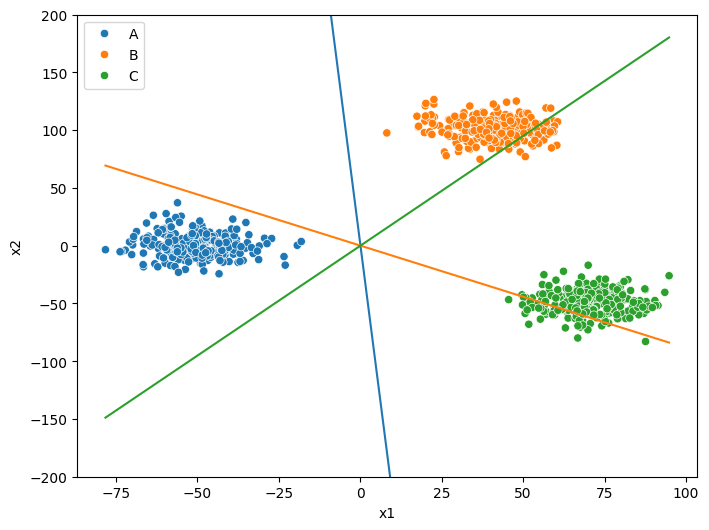

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['x1'],y=df['x2'],hue=df['label'],hue_order=['A','B','C'])
for i in range(3):
    theta0 = reg.intercept_[i]
    theta1 = reg.coef_[i,0]
    theta2 = reg.coef_[i,1]
    x2 = -(theta0+theta1*df['x1'])/theta2
    sns.lineplot(x=df['x1'],y=x2)
plt.ylim((-200,200));

In [11]:
reg.predict([[25,0]])

array(['C'], dtype=object)

In [12]:
reg.predict_proba([[25,0]])

array([[6.15202966e-05, 1.42230353e-01, 8.57708127e-01]])